# Humpback Whale Identification — Metric Learning

**Course**: Machine Learning for Computer Vision (91266)  
**Task**: [Kaggle Whale Identification Playground](https://www.kaggle.com/competitions/whale-categorization-playground)  
**Authors**: Kristoffer Osen & Sebastian Munthe

## Motivation: Why Metric Learning?

The classification baseline (notebook 01) trains a softmax classifier over ~4000 whale
identities. While this learns useful representations, the cross-entropy loss only requires
the embedding space to be **linearly separable** — it does not enforce compact, well-clustered
structure (course slides 11–12). Intra-class distances can be arbitrarily large, and
inter-class distances can be arbitrarily small, as long as a hyperplane separates them.

This is a problem for whale identification because:
1. **Open-world recognition**: new whales appear over time. We can't retrain the classifier
   every time — we need an embedding where k-NN works directly (slides 7–10).
2. **Few-shot classes**: most whales have 1–5 images. A 4000-way softmax can't generalize
   well from 1–2 examples, but a good embedding only needs similar whales to be *close*.
3. **new_whale detection**: a well-structured embedding lets us detect unknowns by distance
   threshold rather than ad-hoc confidence thresholding.

We implement two metric learning approaches from the course:
- **ArcFace** (slides 31–33): modifies softmax with angular margin — still classification
  but produces much better-clustered embeddings.
- **Triplet Loss** (slides 21–24): directly optimizes embedding distances with
  anchor-positive-negative triplets and semi-hard negative mining.


## 1. Setup

In [1]:
import sys, os, gc
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

from config import ExperimentConfig
from experiment import ExperimentManager
from dataset import (
    WhaleDataset,
    build_val_transform,
    prepare_data,
    build_dataloaders,
    build_metric_dataloaders,
 )
from models import WhaleClassifier, build_model, print_model_summary
from losses import build_loss
from training import train, set_seed
from evaluation import evaluate, evaluate_retrieval, extract_embeddings
from visualization import plot_training_history, compare_experiments, list_experiments

device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
                      else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

def cleanup_memory(*var_names, scope=None):
    """Delete notebook variables and force garbage collection."""
    if scope is None:
        scope = globals()
    for name in var_names:
        if name in scope:
            del scope[name]
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        try:
            torch.mps.empty_cache()
        except Exception:
            pass

def build_retrieval_eval_loaders(config, data):
    """Deterministic gallery/query loaders for comparable retrieval metrics."""
    image_dir = os.path.join(config.data_dir, "train")
    eval_transform = build_val_transform(config)

    gallery_dataset = WhaleDataset(
        df=data["train_df"],
        image_dir=image_dir,
        id_to_idx=data["id_to_idx"],
        transform=eval_transform,
    )
    query_dataset = WhaleDataset(
        df=data["val_df"],
        image_dir=image_dir,
        id_to_idx=data["id_to_idx"],
        transform=eval_transform,
    )

    batch_size = config.batch_size * 2
    gallery_loader = DataLoader(
        gallery_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=config.num_workers,
        pin_memory=True,
        drop_last=False,
    )
    query_loader = DataLoader(
        query_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=config.num_workers,
        pin_memory=True,
        drop_last=False,
    )
    return gallery_loader, query_loader

Device: cuda
GPU: NVIDIA GeForce RTX 3070


## 2. Load Data

We reuse the same data preparation as the baseline. The splits are identical
(same seed), so results are directly comparable.


In [2]:
# Use same data config as baseline for fair comparison
data_config = ExperimentConfig(
    data_dir="data",
    seed=42,
    stratified_split=True,
)
data = prepare_data(data_config)

# Shared retrieval-eval protocol used for ALL models in this notebook.
# Keep these values fixed so retrieval metrics are directly comparable.
retrieval_eval_config = ExperimentConfig(
    data_dir=data_config.data_dir,
    seed=data_config.seed,
    stratified_split=data_config.stratified_split,
    batch_size=data_config.batch_size,
    num_workers=data_config.num_workers,
    retrieval_k=5,
    confidence_threshold=0.5,
)
print(
    f"Retrieval eval protocol: k={retrieval_eval_config.retrieval_k}, "
    f"threshold={retrieval_eval_config.confidence_threshold}, "
    f"batch_size={retrieval_eval_config.batch_size}"
)

[split] Stratified test split infeasible on frequent classes; using shuffled split.
[split] Stratified val split infeasible on frequent classes; using shuffled split.
Dataset split:
  Train:    8089 images, 4247 known classes (filtered 647 new_whale)
  Val:       557 images (88 are new_whale)
  Test:      557 images (75 are new_whale)
  Class distribution: min=1 median=1 max=24 samples/class
Retrieval eval protocol: k=5, threshold=0.5, batch_size=12


## 3. Baseline Embedding Quality (Before Metric Learning)

Before training with metric learning, let's visualize how the baseline classifier's
embeddings look. According to the course (slide 11), cross-entropy embeddings are
linearly separable but not necessarily well-clustered — distances within a class
can be large, and distances between classes can be small.

We also run k-NN retrieval evaluation to get a quantitative baseline for embedding quality.


In [3]:
# ── Load the best baseline model ──────────────────────────────────
# UPDATE THIS PATH to point to your best baseline checkpoint
BASELINE_CHECKPOINT = "experiments/20260402_175215_baseline_effnetb5_focal_bd5dccca/checkpoints/best.pth"

# If you haven't trained a baseline yet, skip this section.
# You can come back to it after training with notebook 01.

try:
    ckpt_path = Path(BASELINE_CHECKPOINT)
    baseline_config_path = ckpt_path.parent.parent / "config.json"
    baseline_train_config = ExperimentConfig.load(str(baseline_config_path))

    baseline_model = build_model(
        baseline_train_config,
        num_classes=data["num_classes"],
        device=device,
    )

    state = torch.load(BASELINE_CHECKPOINT, map_location=device, weights_only=False)
    baseline_model.load_state_dict(state["model_state_dict"])

    print("Baseline model loaded successfully.")
    print(f"Using baseline training config: {baseline_config_path}")

    # Retrieval evaluation with shared protocol (comparable across models)
    train_loader, val_loader = build_retrieval_eval_loaders(retrieval_eval_config, data)

    print("\nBaseline retrieval performance:")
    baseline_retrieval = evaluate_retrieval(
        baseline_model, train_loader, val_loader,
        retrieval_eval_config, device,
    )

    # Release temporary dataloaders before t-SNE
    cleanup_memory("train_loader", "val_loader")
except FileNotFoundError:
    print(f"Baseline checkpoint not found at: {BASELINE_CHECKPOINT}")
    print("Train the baseline first using notebook 01, then update the path above.")
    baseline_model = None

Baseline model loaded successfully.
Using baseline training config: experiments\20260402_175215_baseline_effnetb5_focal_bd5dccca\config.json

Baseline retrieval performance:


  Extracting embeddings:   0%|          | 0/338 [00:07<?, ?it/s]

  Gallery: 8089 embeddings, 4247 identities


  Extracting embeddings:   0%|          | 0/24 [00:08<?, ?it/s]

  Recall@1: 49.68%  Recall@5: 60.17%  NewWhale Det: 0.00%


### 3.1 t-SNE Visualization of Baseline Embeddings

t-SNE projects the high-dimensional embeddings to 2D for visualization.
If the baseline embedding is well-structured, we should see clusters — but
as the course predicts (slide 11), cross-entropy embeddings tend to form
elongated rays rather than compact blobs.


In [4]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

  Extracting embeddings:   0%|          | 0/24 [00:07<?, ?it/s]

  Extracting embeddings:   0%|          | 0/674 [00:08<?, ?it/s]

t-SNE: 221 points, 10 classes (min 5/class)


C:\Users\krios\AppData\Local\Temp\ipykernel_7404\2588758607.py:74: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10" if n_classes <= 10 else "tab20")


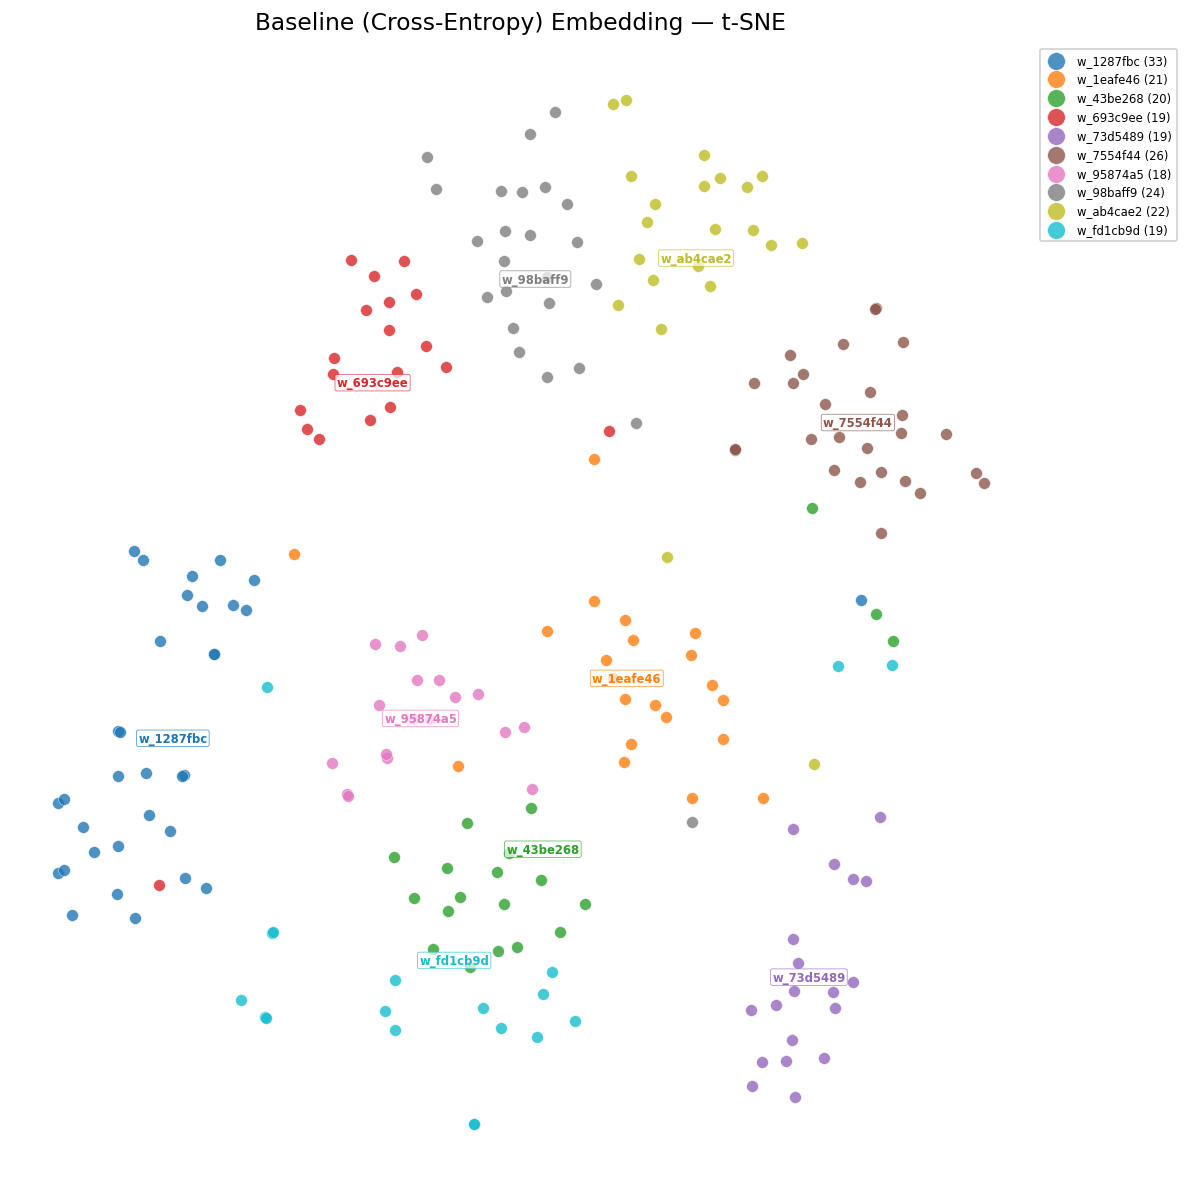

  Perplexity used: 27 | KL divergence: 0.54


In [5]:
from sklearn.manifold import TSNE

def plot_embedding_tsne(model, loader, data, device, title="",
                        max_samples=500, top_k_classes=10,
                        min_samples_per_class=5, combine_loaders=None):
    """
    Extract embeddings and plot t-SNE colored by class.
    
    Args:
        combine_loaders: Optional list of extra DataLoaders to pool with `loader`
                         for more points (e.g. [train_loader]) — only affects
                         the plot, not evaluation metrics.
    """
    # Gather embeddings from primary + optional extra loaders
    all_emb, all_lab = extract_embeddings(model, loader, device)
    if combine_loaders:
        for extra_loader in combine_loaders:
            e, l = extract_embeddings(model, extra_loader, device)
            all_emb = torch.cat([all_emb, e], dim=0)
            all_lab = torch.cat([all_lab, l], dim=0)

    # Filter to known whales only
    known_mask = all_lab >= 0
    emb = all_emb[known_mask].numpy()
    lab = all_lab[known_mask].numpy()

    # Keep only classes with enough samples for visible clusters
    unique, counts = np.unique(lab, return_counts=True)
    frequent = unique[counts >= min_samples_per_class]
    if len(frequent) == 0:
        print(f"No classes have ≥{min_samples_per_class} samples. "
              f"Lowering threshold to 2.")
        frequent = unique[counts >= 2]
    if len(frequent) == 0:
        print("Not enough data to plot meaningful t-SNE.")
        return

    # Pick top-K most frequent among those
    freq_counts = {c: counts[unique == c][0] for c in frequent}
    top_classes = sorted(freq_counts, key=freq_counts.get, reverse=True)[:top_k_classes]
    class_mask = np.isin(lab, top_classes)
    emb = emb[class_mask]
    lab = lab[class_mask]

    # Subsample if needed
    if len(emb) > max_samples:
        idx = np.random.choice(len(emb), max_samples, replace=False)
        emb, lab = emb[idx], lab[idx]

    n_points = len(emb)
    n_classes = len(np.unique(lab))
    print(f"t-SNE: {n_points} points, {n_classes} classes "
          f"(min {min_samples_per_class}/class)")

    # Auto-tune perplexity: should be much less than n_points,
    # but high enough to capture local structure
    perplexity = min(max(n_points // 8, 5), 50)

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=42,
        max_iter=1500,
        init="pca",
        learning_rate="auto",
        n_jobs=-1,
    )
    emb_2d = tsne.fit_transform(emb)

    # ── Plot ─────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))

    # Use a colormap with good perceptual separation
    cmap = plt.cm.get_cmap("tab10" if n_classes <= 10 else "tab20")
    classes_sorted = sorted(np.unique(lab))

    for i, c in enumerate(classes_sorted):
        mask = lab == c
        color = cmap(i % cmap.N)
        whale_name = data["idx_to_id"].get(int(c), str(c))[:12]
        count = mask.sum()

        ax.scatter(
            emb_2d[mask, 0], emb_2d[mask, 1],
            s=50, alpha=0.8, color=color, edgecolors="white",
            linewidths=0.3, label=f"{whale_name} ({count})", zorder=2,
        )

        # Centroid label for each cluster
        cx, cy = emb_2d[mask, 0].mean(), emb_2d[mask, 1].mean()
        ax.annotate(
            whale_name, (cx, cy), fontsize=7, fontweight="bold",
            color=color, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec=color,
                      alpha=0.7, lw=0.5),
            zorder=3,
        )

    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.legend(
        fontsize=7, markerscale=1.5, loc="upper left",
        bbox_to_anchor=(1.01, 1), borderaxespad=0,
        frameon=True, framealpha=0.9,
    )

    plt.tight_layout()
    plt.show()

    print(f"  Perplexity used: {perplexity} | KL divergence: {tsne.kl_divergence_:.2f}")


# ── Usage ────────────────────────────────────────────────────────────────
# Combine train + val loaders to get enough points per class for visible clusters.
# This is purely for visualization — evaluation metrics stay on val only.
if baseline_model is not None:
    train_loader_viz, val_loader_viz = build_dataloaders(data_config, data)
    plot_embedding_tsne(
        baseline_model, val_loader_viz, data, device,
        title="Baseline (Cross-Entropy) Embedding — t-SNE",
        top_k_classes=10,
        min_samples_per_class=5,
        combine_loaders=[train_loader_viz],
    )

## 4. ArcFace Training

**ArcFace** (Deng et al., CVPR 2019 — course slides 31–33) modifies the classification
head to enforce angular margin between classes on a hypersphere.

Instead of computing logits as `W · f(x)`, ArcFace:
1. L2-normalizes both weight vectors and embeddings
2. Computes cosine similarity (= angular distance on the hypersphere)
3. Adds an angular penalty `m` to the correct class's angle
4. Scales by factor `s` before softmax

This forces the model to cluster same-class embeddings tightly and push different
classes apart by at least `m` radians. The key advantage over triplet loss:
**no pair/triplet mining is needed** — ArcFace works with standard batching (slide 31).

We initialize from the baseline's backbone + embedding weights, replacing only
the classifier head with the ArcFace head.


In [6]:
config_arcface = ExperimentConfig(
    # ── Metadata ─────────────────────────────────────────────────
    experiment_name="arcface_effnetb5",
    description="ArcFace angular margin loss, initialized from baseline",

    # ── Paths ────────────────────────────────────────────────────
    data_dir="data",
    experiments_root="experiments",

    # ── Model ────────────────────────────────────────────────────
    backbone="efficientnet_b5",
    image_size=(456, 456),
    embedding_dim=512,
    head_type="arcface",       # ← ArcFace head instead of linear
    arcface_scale=30.0,        # Logit scale factor
    arcface_margin=0.5,        # Angular margin (radians)

    # ── Training ─────────────────────────────────────────────────
    freeze_backbone_epochs=2,  # Shorter freeze: backbone is already good from baseline
    freeze_bn=True,
    epochs=20,
    batch_size=12,
    accumulation_steps=2,
    use_amp=True,

    # ── Optimizer ────────────────────────────────────────────────
    lr_head=5e-4,              # Slightly lower than baseline (fine-tuning, not fresh)
    lr_backbone=5e-5,
    weight_decay=1e-4,

    # ── Loss ─────────────────────────────────────────────────────
    loss_type="arcface_ce",    # Standard CE on the ArcFace-modified logits
    label_smoothing=0.0,       # No label smoothing with ArcFace (margin handles it)
    use_class_weights=False,   # ArcFace margin handles class separation

    # ── Scheduler ────────────────────────────────────────────────
    scheduler="cosine",
    warmup_epochs=1,

    # ── Early stopping ───────────────────────────────────────────
    early_stopping_patience=6,
    early_stopping_metric="val_known_acc",

    # ── Initialize from baseline ─────────────────────────────────
    # UPDATE THIS PATH to your best baseline checkpoint:
    init_from_checkpoint=BASELINE_CHECKPOINT if 'BASELINE_CHECKPOINT' in dir() else None,

    seed=42,
)

print("ArcFace config:")
print(config_arcface.summary())


ArcFace config:
efficientnet_b5 | 456px | arcface_ce(γ=2.0) | lr=5e-05/0.0005 | freeze=2ep | bs=12×2 | head=arcface(s=30.0,m=0.5)


In [7]:
# ═══════════════════════════════════════════════════════════════════
# TRAIN ARCFACE
# ═══════════════════════════════════════════════════════════════════
manager_arcface = train(config_arcface, data, device)


[01:37:10] Resumed experiment: 20260403_163615_arcface_effnetb5_6c8d152f
[01:37:10] Config: efficientnet_b5 | 456px | arcface_ce(γ=2.0) | lr=5e-05/0.0005 | freeze=2ep | bs=12×2 | head=arcface(s=30.0,m=0.5)
[01:37:10] Resume mode active for experiment: 20260403_163615_arcface_effnetb5_6c8d152f
Loading backbone + embedding from: experiments/20260402_175215_baseline_effnetb5_focal_bd5dccca/checkpoints/best.pth
  Loaded 859 parameter tensors (backbone + embedding)
[01:37:11] Resume checkpoint indicates UNFROZEN optimizer state.

Model: efficientnet_b5 (head=arcface)
  Input size:     (456, 456)
  Embedding dim:  512
  Total params:     31,565,360
  Backbone:         28,340,784
  Head:              3,224,576
  Trainable:        31,565,360 (100.0%)
  Frozen:                    0 (0.0%)

[01:37:11] Loss: arcface_ce | Head: arcface
[01:37:11] Loading checkpoint: experiments\20260403_163615_arcface_effnetb5_6c8d152f\checkpoints\latest.pth
[01:37:12] Resuming from epoch 20
[01:37:12] 
Starting t

### 4.1 ArcFace Training Analysis

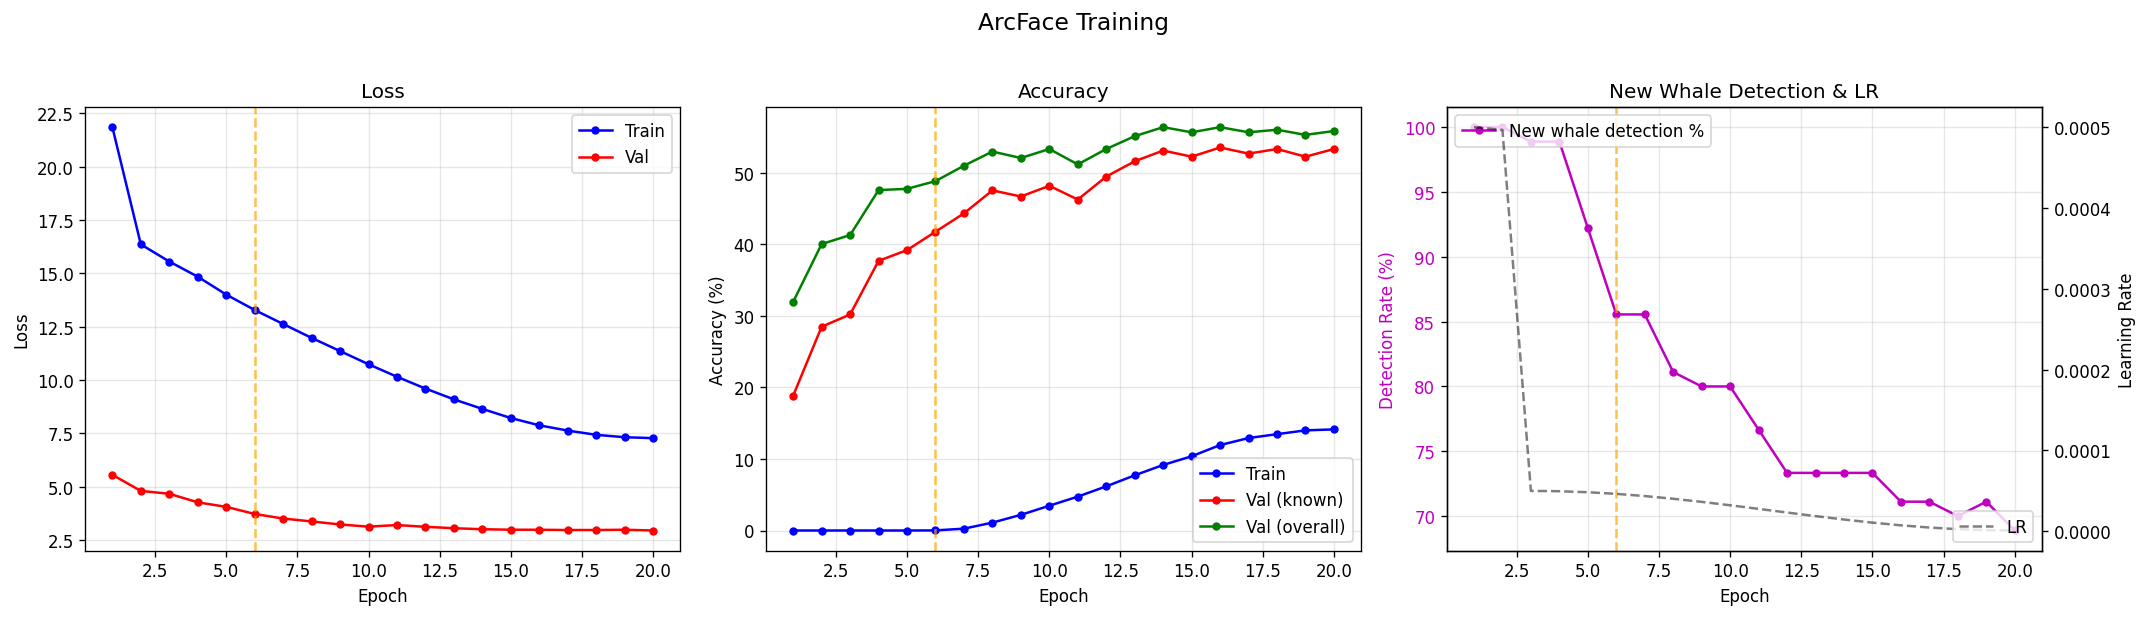

In [8]:
import json

with open(manager_arcface.root / "metrics.json", "r") as f:
    arcface_metrics = json.load(f)

plot_training_history(arcface_metrics, title="ArcFace Training")


### 4.2 ArcFace Embedding Quality

The ArcFace embedding should show much tighter, more separated clusters
compared to the baseline — this is the key result to demonstrate.


Loading backbone + embedding from: experiments/20260402_175215_baseline_effnetb5_focal_bd5dccca/checkpoints/best.pth
  Loaded 859 parameter tensors (backbone + embedding)
[01:37:13] Loading checkpoint: experiments\20260403_163615_arcface_effnetb5_6c8d152f\checkpoints\best.pth
[01:37:13] Resuming from epoch 16
ArcFace retrieval performance:


  Extracting embeddings:   0%|          | 0/338 [00:07<?, ?it/s]

  Gallery: 8089 embeddings, 4247 identities


  Extracting embeddings:   0%|          | 0/24 [00:06<?, ?it/s]

  Recall@1: 70.66%  Recall@5: 77.73%  NewWhale Det: 0.00%


  Extracting embeddings:   0%|          | 0/24 [00:06<?, ?it/s]

  Extracting embeddings:   0%|          | 0/338 [00:07<?, ?it/s]

t-SNE: 221 points, 10 classes (min 5/class)


C:\Users\krios\AppData\Local\Temp\ipykernel_7404\2588758607.py:74: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10" if n_classes <= 10 else "tab20")


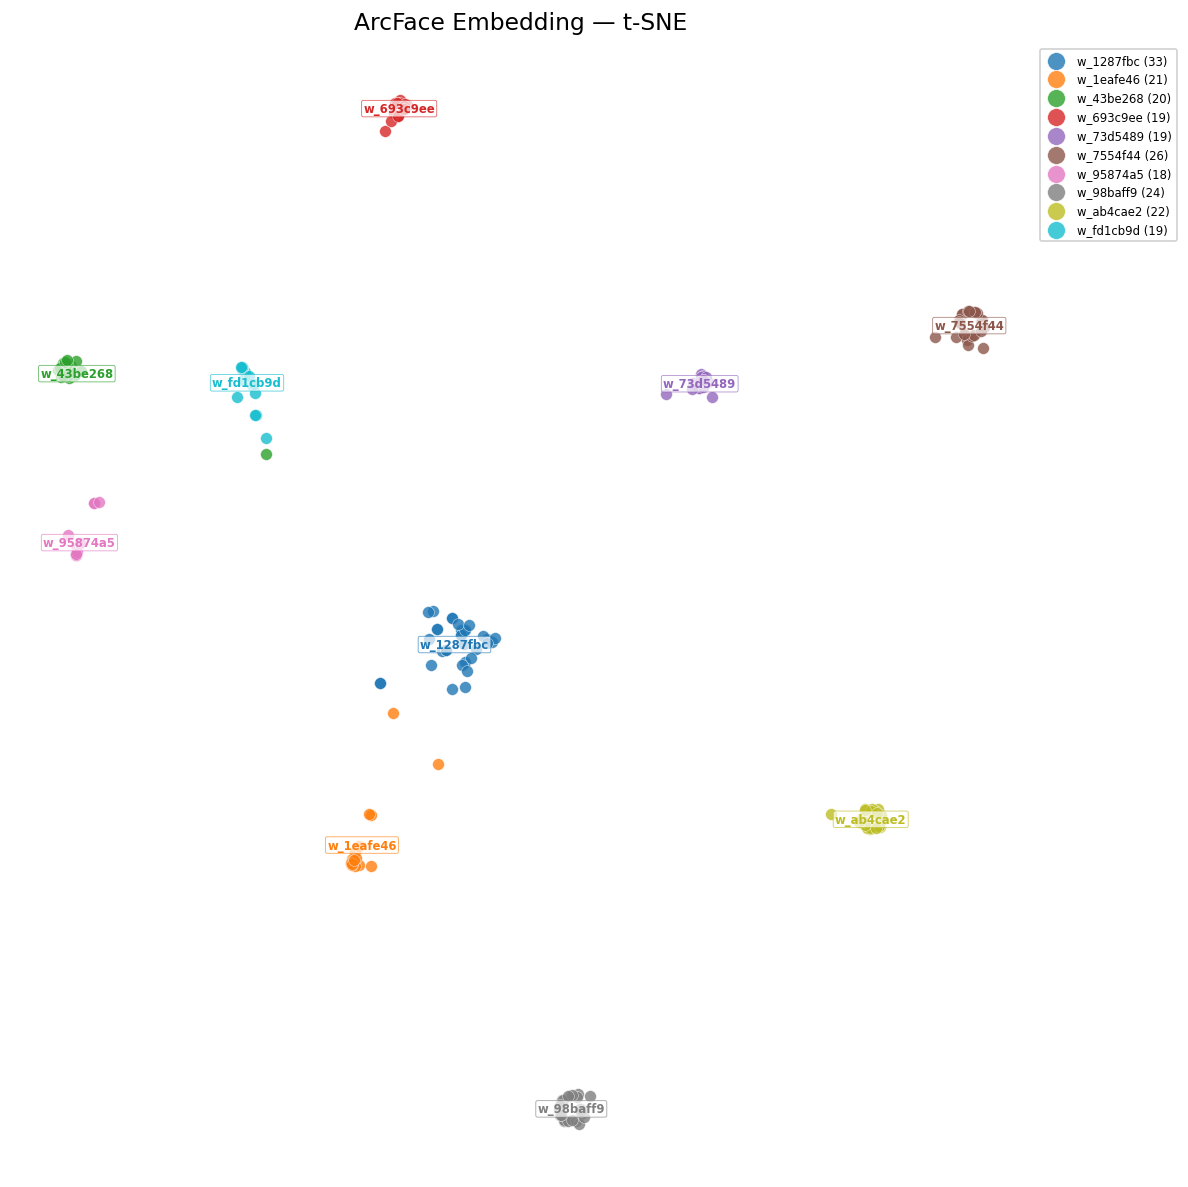

  Perplexity used: 27 | KL divergence: 0.08


In [9]:
# Load best ArcFace model
arcface_model = build_model(config_arcface, data["num_classes"], device)
manager_arcface.load_checkpoint(arcface_model, checkpoint="best")

train_loader, val_loader = build_retrieval_eval_loaders(retrieval_eval_config, data)

print("ArcFace retrieval performance:")
arcface_retrieval = evaluate_retrieval(
    arcface_model, train_loader, val_loader, retrieval_eval_config, device,
)

plot_embedding_tsne(arcface_model, val_loader, data, device,
                    title="ArcFace Embedding — t-SNE", combine_loaders=[train_loader])

cleanup_memory("train_loader", "val_loader")

In [10]:
# Strong cleanup before triplet training.
# Keep reusable notebook context (data/configs/metrics) and remove only heavy artifacts.
import sys
from IPython import get_ipython

to_cleanup = [
    # Models / trainers
    "manager_arcface",
    "manager_triplet",
    # DataLoader / batch tensors
    "train_loader", "val_loader", "train_loader_viz", "val_loader_viz",
    "gallery_loader", "query_loader",
    "images", "labels", "logits", "embeddings", "loss", "batch", "outputs",
    # Training internals
    "model", "optimizer", "scheduler", "criterion", "scaler", "pbar",
    "train_metrics", "val_metrics", "all_metrics",
    # Temporary checkpoint vars
    "state", "model_state", "resume_state", "ckpt_path",
    # Large traceback alias often created in except blocks
    "e",
]

for name in to_cleanup:
    if name in globals():
        del globals()[name]

# Clear exception references that can pin large tensors after crashes.
for attr in ("last_traceback", "last_type", "last_value"):
    if hasattr(sys, attr):
        setattr(sys, attr, None)

ip = get_ipython()
if ip is not None:
    # Keep normal variables; only clear output history references that may keep tensors alive.
    ip.user_ns.pop("_", None)
    ip.user_ns.pop("__", None)
    ip.user_ns.pop("___", None)
    out_dict = ip.user_ns.get("Out", None)
    if isinstance(out_dict, dict):
        out_dict.clear()
    if hasattr(ip, "displayhook") and hasattr(ip.displayhook, "flush"):
        ip.displayhook.flush()

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    if hasattr(torch.cuda, "ipc_collect"):
        torch.cuda.ipc_collect()
if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    try:
        torch.mps.empty_cache()
    except Exception:
        pass

print("Memory cleanup complete. Reusable variables (e.g., data/configs/metrics) were kept.")
if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated() / (1024 ** 3)
    reserved = torch.cuda.memory_reserved() / (1024 ** 3)
    print(f"CUDA allocated: {allocated:.2f} GB | reserved: {reserved:.2f} GB")
    if allocated > 2.0:
        print("Allocated memory is still high. Restart kernel for a guaranteed clean GPU state.")

Memory cleanup complete. Reusable variables (e.g., data/configs/metrics) were kept.
CUDA allocated: 0.25 GB | reserved: 0.53 GB


## 5. Triplet Loss Training

**Triplet Loss** (Schroff et al., FaceNet, CVPR 2015 — course slides 21–24) directly
optimizes embedding distances. For each triplet (anchor, positive, negative):

$$L(A, P, N) = \max\{0,\ \|f(A) - f(P)\|^2 - \|f(A) - f(N)\|^2 + m\}$$

Key implementation details:
- **PK Sampling** (slide 24): each batch contains P identities × K images, ensuring
  valid anchor-positive pairs exist in every batch.
- **Semi-hard negative mining**: negatives that are farther than the positive but within
  the margin — provides the most useful gradient signal.
- **Limitation**: classes with only 1 image cannot participate (no positive pair possible).
  This significantly reduces the usable training set — a real limitation worth discussing.

The model uses `head_type="none"` — no classifier, only the L2-normalized embedding.


In [11]:
config_triplet = ExperimentConfig(
    # ── Metadata ─────────────────────────────────────────────────
    experiment_name="triplet_effnetb5",
    description="Triplet loss with semi-hard mining, PK sampling",

    # ── Paths ────────────────────────────────────────────────────
    data_dir="data",
    experiments_root="experiments",

    # ── Model ────────────────────────────────────────────────────
    backbone="efficientnet_b5",
    image_size=(456, 456),
    embedding_dim=512,
    head_type="none",          # ← No classifier, embedding-only

    # ── Training ─────────────────────────────────────────────────
    freeze_backbone_epochs=2,
    freeze_bn=True,
    epochs=20,
    batch_size=8,              # Not directly used — PK determines batch size
    accumulation_steps=2,      # PK batches are already large
    use_amp=True,

    # ── PK Sampling ──────────────────────────────────────────────
    pk_sampling=True,
    pk_p=4,                   # 4 identities per batch
    pk_k=4,                    # 4 images per identity → batch of 16
    pk_min_samples=2,          # Need ≥2 images to form anchor-positive pairs

    # ── Loss ─────────────────────────────────────────────────────
    loss_type="triplet",
    triplet_margin=0.3,
    triplet_mining="semi_hard",
    use_class_weights=False,   # Not applicable for triplet loss

    # ── Optimizer ────────────────────────────────────────────────
    lr_head=5e-4,
    lr_backbone=5e-5,
    weight_decay=1e-4,

    # ── Scheduler ────────────────────────────────────────────────
    scheduler="cosine",
    warmup_epochs=1,

    # ── Early stopping ───────────────────────────────────────────
    early_stopping_patience=6,
    early_stopping_metric="val_known_acc",  # Mapped from retrieval_recall@1

    # ── Initialize from baseline ─────────────────────────────────
    init_from_checkpoint=BASELINE_CHECKPOINT if 'BASELINE_CHECKPOINT' in dir() else None,

    seed=42,
)

print("Triplet config:")
print(config_triplet.summary())


Triplet config:
efficientnet_b5 | 456px | triplet(γ=2.0) | lr=5e-05/0.0005 | freeze=2ep | bs=8×2 | head=none | triplet(m=0.3,semi_hard) | PK(4×4)


In [12]:
# ═══════════════════════════════════════════════════════════════════
# TRAIN TRIPLET
# ═══════════════════════════════════════════════════════════════════
manager_triplet = train(config_triplet, data, device)


[01:41:55] Resumed experiment: 20260404_143337_triplet_effnetb5_3ae3db53
[01:41:55] Config: efficientnet_b5 | 456px | triplet(γ=2.0) | lr=5e-05/0.0005 | freeze=2ep | bs=8×2 | head=none | triplet(m=0.3,semi_hard) | PK(4×4)
[01:41:55] Matching experiment is already completed. Skipping training and reusing existing checkpoints.


### 5.1 Triplet Training Analysis

c:\Users\krios\Downloads\ML4CV\visualization.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left")


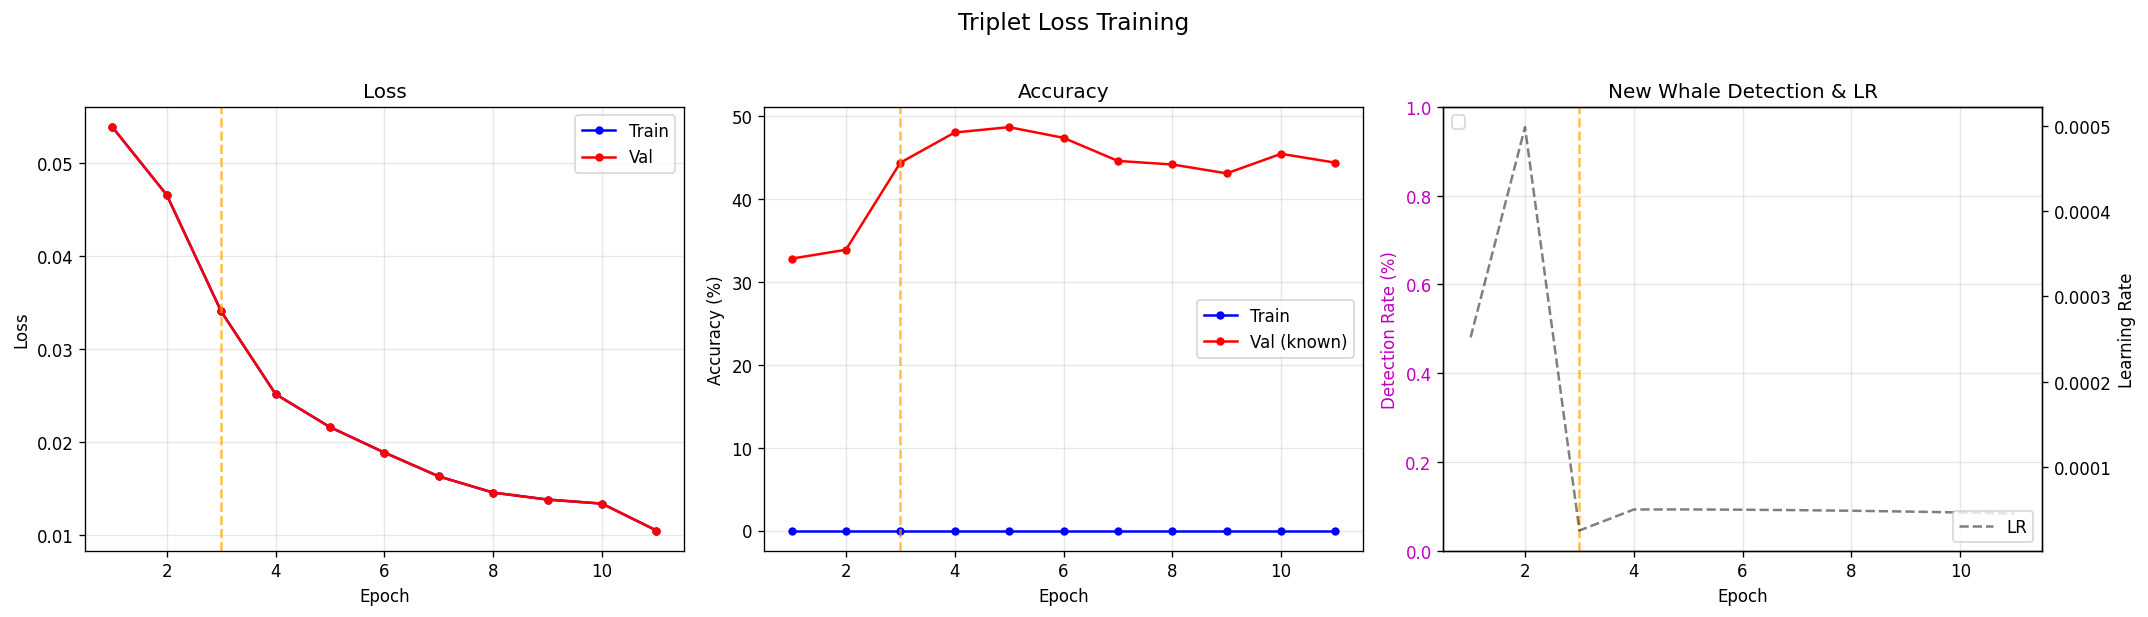

In [13]:
with open(manager_triplet.root / "metrics.json", "r") as f:
    triplet_metrics = json.load(f)

plot_training_history(triplet_metrics, title="Triplet Loss Training")


### 5.2 Triplet Embedding Quality

Loading backbone + embedding from: experiments/20260402_175215_baseline_effnetb5_focal_bd5dccca/checkpoints/best.pth
  Loaded 859 parameter tensors (backbone + embedding)
[01:41:56] Loading checkpoint: experiments\20260404_143337_triplet_effnetb5_3ae3db53\checkpoints\best.pth
[01:41:57] Resuming from epoch 5
Triplet retrieval performance:


  Extracting embeddings:   0%|          | 0/338 [00:08<?, ?it/s]

  Gallery: 8089 embeddings, 4247 identities


  Extracting embeddings:   0%|          | 0/24 [00:07<?, ?it/s]

  Recall@1: 66.38%  Recall@5: 76.23%  NewWhale Det: 0.00%


  Extracting embeddings:   0%|          | 0/24 [00:07<?, ?it/s]

  Extracting embeddings:   0%|          | 0/338 [00:07<?, ?it/s]

t-SNE: 221 points, 10 classes (min 5/class)


C:\Users\krios\AppData\Local\Temp\ipykernel_7404\2588758607.py:74: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10" if n_classes <= 10 else "tab20")


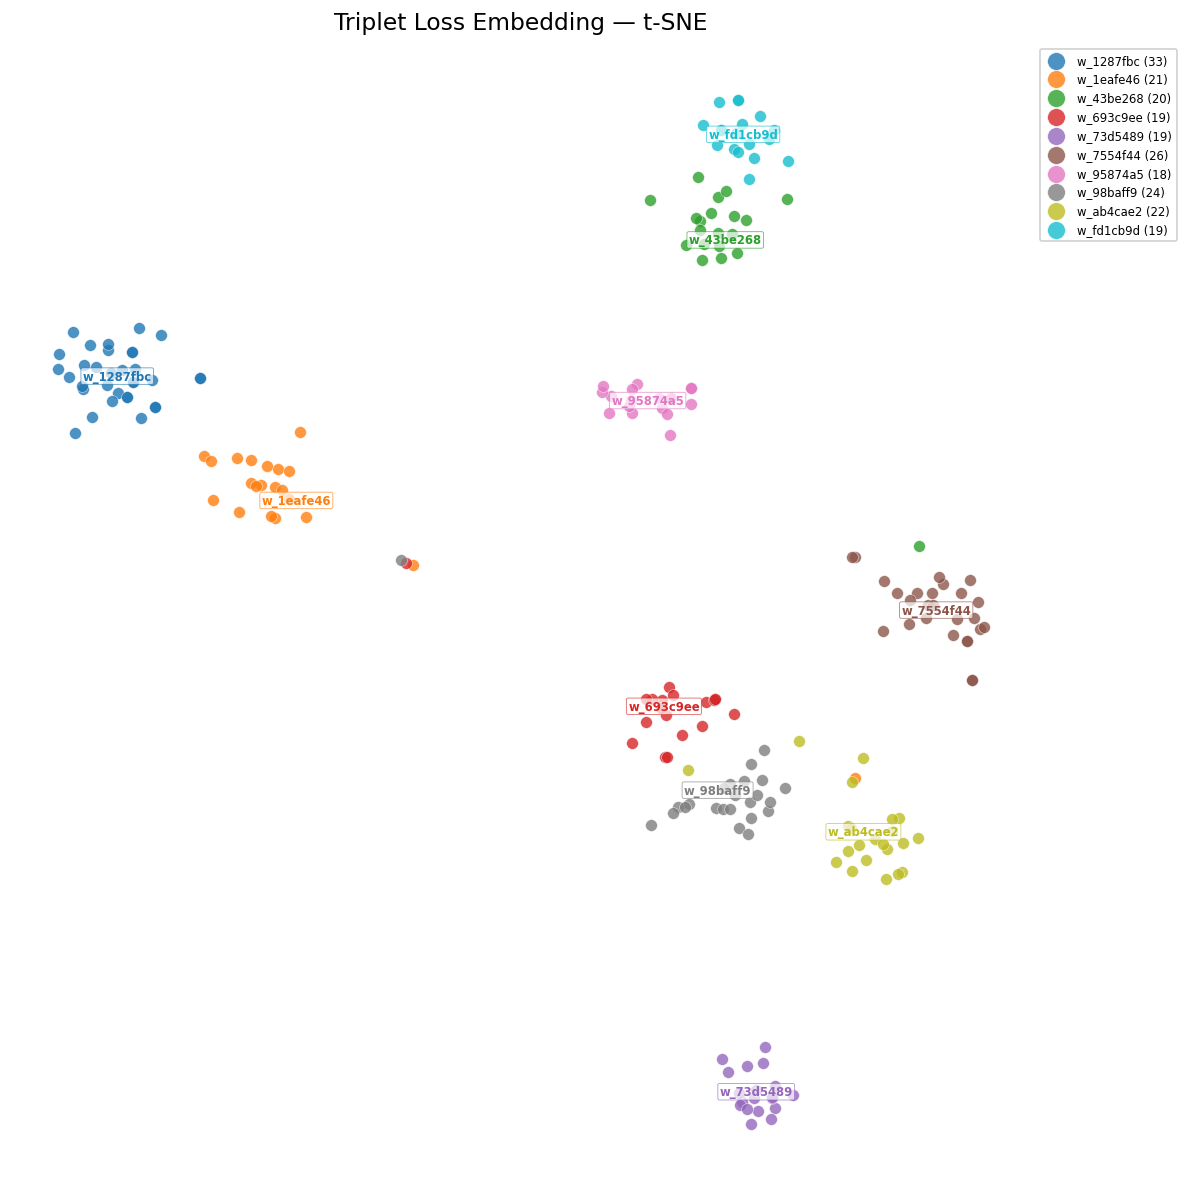

  Perplexity used: 27 | KL divergence: 0.19


In [14]:
triplet_model = build_model(config_triplet, data["num_classes"], device)
manager_triplet.load_checkpoint(triplet_model, checkpoint="best")

train_loader, val_loader = build_retrieval_eval_loaders(retrieval_eval_config, data)

print("Triplet retrieval performance:")
triplet_retrieval = evaluate_retrieval(
    triplet_model, train_loader, val_loader, retrieval_eval_config, device,
)

plot_embedding_tsne(triplet_model, val_loader, data, device,
                    title="Triplet Loss Embedding — t-SNE", combine_loaders=[train_loader])

cleanup_memory("train_loader", "val_loader")

## 6. Comparison

### Approach Summary

| Approach | Loss | Head | Batching | From Course |
|----------|------|------|----------|-------------|
| Baseline | Focal (CE variant) | Linear classifier | Random shuffle | — |
| ArcFace | CE on angular-margin logits | ArcFace head | Random shuffle | Slides 31–33 |
| Triplet | Triplet with semi-hard mining | None (embedding only) | PK sampling | Slides 21–24 |

### Key Differences
- **ArcFace** is still classification at training time but produces metric-learning-quality
  embeddings. No special batching needed. (Slide 31: "bypasses the problem of sampling
  informative pairs/triplets.")
- **Triplet loss** directly optimizes distances but requires PK sampling and can only use
  classes with ≥2 images. More hyperparameters to tune (margin, mining strategy).
- The **metric learning reality check** (slide 41, Musgrave et al. ECCV 2020) found that
  with the same hyperparameters, differences between metric learning losses are modest —
  what matters most is the backbone and training recipe.


In [15]:
# ── Side-by-side comparison ───────────────────────────────────────
print(f"{'Metric':<35s} {'Baseline':>10s} {'ArcFace':>10s} {'Triplet':>10s}")
print("-" * 70)

for key, label in [
    ("retrieval_recall@1", "Retrieval Recall@1"),
    ("retrieval_recall@k", "Retrieval Recall@5"),
    ("retrieval_new_whale_detection", "New Whale Detection"),
    ("retrieval_mean_pos_sim", "Mean Positive Similarity"),
    ("retrieval_mean_neg_sim", "Mean Negative Similarity"),
]:
    b = baseline_retrieval.get(key, 0) if baseline_model is not None else 0
    a = arcface_retrieval.get(key, 0)
    t = triplet_retrieval.get(key, 0)

    if "sim" in key:
        print(f"  {label:<33s} {b:>10.4f} {a:>10.4f} {t:>10.4f}")
    else:
        print(f"  {label:<33s} {b*100:>9.2f}% {a*100:>9.2f}% {t*100:>9.2f}%")


Metric                                Baseline    ArcFace    Triplet
----------------------------------------------------------------------
  Retrieval Recall@1                    49.68%     70.66%     66.38%
  Retrieval Recall@5                    60.17%     77.73%     76.23%
  New Whale Detection                    0.00%      0.00%      0.00%
  Mean Positive Similarity              0.8252     0.8042     0.8784
  Mean Negative Similarity              0.7369     0.6237     0.7996


In [16]:
# Compare training curves across all experiments
list_experiments(config_arcface.experiments_root)


ID                                             Best Metric Best Epoch  Summary
------------------------------------------------------------------------------------------------------------------------
20260402_175215_baseline_effnetb5_focal_bd5dccca          N/A        N/A  efficientnet_b5 | 456px | arcface_ce(γ=2.0) | lr=5e-05/0.0005 | freeze=2ep | bs=12×2 | head=arcface(s=30.0,m=0.5)
20260403_163615_arcface_effnetb5_6c8d152f           0.5353         15  efficientnet_b5 | 456px | arcface_ce(γ=2.0) | lr=5e-05/0.0005 | freeze=2ep | bs=12×2 | head=arcface(s=30.0,m=0.5)
20260404_103356_triplet_effnetb5_f82ef70d              N/A        N/A  efficientnet_b5 | 456px | triplet(γ=2.0) | lr=5e-05/0.0005 | freeze=2ep | bs=8×1 | head=none | triplet(m=0.3,semi_hard) | PK(16×4)
20260404_141016_triplet_effnetb5_7844ee93              N/A        N/A  efficientnet_b5 | 456px | triplet(γ=2.0) | lr=5e-05/0.0005 | freeze=2ep | bs=8×2 | head=none | triplet(m=0.3,semi_hard) | PK(8×4)
20260404_143337_triplet_

In [17]:
# Overlay val accuracy (or retrieval recall) for all experiments
# compare_experiments("experiments", metric="val_known_acc")


## 7. Discussion

### What We Learned

*Fill in after running experiments — discuss:*
- Which approach gave the best retrieval performance?
- How did the t-SNE visualizations differ between baseline and metric learning?
- Did ArcFace or triplet loss produce tighter clusters?
- How well did new_whale detection work via distance thresholding vs. confidence?
- What was the impact of PK sampling's class-count limitation on triplet training?
- How do these results relate to the "metric learning reality check" (slide 41)?

### Limitations
- Classes with only 1 image can't participate in triplet training
- We didn't explore all losses covered in the course (contrastive, NT-Xent/InfoNCE)
- The dataset is relatively small — metric learning benefits more with larger data
- No test-time augmentation or ensemble methods were used

### Connection to Course Material
- Slides 5–10: whale identification as an open-world re-identification problem
  (directly analogous to face recognition)
- Slides 11–12: cross-entropy embeddings are linearly separable but not clustered
- Slides 14–16: siamese network training / metric learning objectives
- Slides 18–19: contrastive loss
- Slides 21–24: triplet loss with margin and semi-hard negative mining
- Slides 31–33: ArcFace angular margin loss
- Slide 41: metric learning reality check — losses matter less than recipes
